# Control de calidad y análisis de sensibilidad a artefactos de CTE-Net

Este cuaderno realiza un análisis **post hoc**, sin cargar checkpoints y sin
volver a entrenar el modelo. Reconstruye las mismas ventanas de 4 s utilizadas
por CTE-Net, calcula indicadores básicos de calidad de señal, los relaciona con
las predicciones *out-of-fold* ya guardadas y recalcula el rendimiento después
de excluir ventanas potencialmente contaminadas.

Los indicadores empleados son sensibles, pero no específicos, a artefactos.
Por esta razón, las ventanas señaladas se denominan *potentially contaminated
windows* y no se interpretan como artefactos confirmados.

In [1]:
from __future__ import annotations

import json
import os
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import welch
from scipy.stats import kurtosis, spearmanr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

FS = 128
WINDOW_SAMPLES = 512
WINDOW_STEP = 256
PRIMARY_ROBUST_Z = 5.0
ROBUST_Z_VALUES = (4.0, 5.0, 6.0)
N_BOOTSTRAP = 5_000
BOOTSTRAP_SEED = 20260830

# En una prueba rápida puede definirse CTE_NET_QC_SMOKE_TEST=1.
if os.environ.get("CTE_NET_QC_SMOKE_TEST") == "1":
    N_BOOTSTRAP = 100

DATASET_ROOT = Path(
    os.environ.get(
        "CTE_NET_DATASET_ROOT",
        "/kaggle/input/datasets/daprosero/mi-tdah-dataset/"
        "MI_TDAH_Dataset/TDAH",
    )
)

EEG_ROOT = DATASET_ROOT / "ieee"
ADHD_ROOT = EEG_ROOT / "ADHD_group"
CONTROL_ROOT = EEG_ROOT / "Control_group"

RESULTS_ROOT = Path(
    os.environ.get(
        "CTE_NET_RESULTS_ROOT",
        "/kaggle/input/datasets/alejandragomezr/results-models-c-tenet",
    )
)

PREDICTIONS_NAME = "CTE_Net_all_window_predictions.csv"

OUTPUT_ROOT = Path(
    os.environ.get(
        "CTE_NET_QC_OUTPUT_ROOT",
        "/kaggle/working/CTE_Net_artifact_quality_sensitivity",
    )
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CHANNEL_NAMES = [
    "Fz", "Cz", "Pz", "C3", "T3", "C4", "T4", "Fp1", "Fp2",
    "F3", "F4", "F7", "F8", "P3", "P4", "T5", "T6", "O1", "O2",
]
FRONTAL_INDICES = [CHANNEL_NAMES.index("Fp1"), CHANNEL_NAMES.index("Fp2")]

print("Raíz del EEG:", EEG_ROOT)
print("Raíz de resultados:", RESULTS_ROOT)
print("Carpeta de salida:", OUTPUT_ROOT)
print("Bootstrap:", N_BOOTSTRAP)

Raíz del EEG: /kaggle/input/datasets/daprosero/mi-tdah-dataset/MI_TDAH_Dataset/TDAH/ieee
Raíz de resultados: /kaggle/input/datasets/alejandragomezr/results-models-c-tenet
Carpeta de salida: /kaggle/working/CTE_Net_artifact_quality_sensitivity
Bootstrap: 5000


## 1. Localización y normalización de las predicciones guardadas

In [2]:
def find_unique_file(root: Path, filename: str) -> Path:
    direct = root / filename
    if direct.exists():
        return direct

    matches = sorted(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"No se encontró {filename!r} dentro de:\n{root}"
        )
    if len(matches) > 1:
        print("ADVERTENCIA: se encontraron varias coincidencias:")
        for match in matches:
            print(" -", match)
        print("Se utilizará:", matches[0])
    return matches[0]


def rename_first_available(
    frame: pd.DataFrame,
    target: str,
    candidates: tuple[str, ...],
) -> pd.DataFrame:
    if target in frame.columns:
        return frame

    normalized = {str(column).strip().lower(): column for column in frame.columns}
    for candidate in candidates:
        original = normalized.get(candidate.lower())
        if original is not None:
            return frame.rename(columns={original: target})
    return frame


def normalize_prediction_columns(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    aliases = {
        "subject_id": (
            "subject", "subject_name", "participant", "participant_id", "sbj"
        ),
        "window_id": (
            "window", "window_name", "segment", "segment_id", "epoch_id"
        ),
        "seed": ("random_seed", "base_seed", "repeat", "repetition"),
        "fold": ("fold_id", "test_fold"),
        "y_true": ("label", "true_label", "target", "class_true"),
        "prob_adhd": (
            "y_prob", "probability", "prob", "adhd_probability", "score"
        ),
    }

    for target, candidates in aliases.items():
        frame = rename_first_available(frame, target, candidates)

    required = {"subject_id", "window_id", "seed", "fold", "y_true", "prob_adhd"}
    missing = required - set(frame.columns)
    if missing:
        raise KeyError(
            "El archivo de predicciones no contiene las columnas requeridas: "
            f"{sorted(missing)}. Columnas disponibles: {frame.columns.tolist()}"
        )

    frame["subject_id"] = frame["subject_id"].astype(str).str.strip()
    frame["seed"] = pd.to_numeric(frame["seed"], errors="raise").astype(int)
    frame["fold"] = pd.to_numeric(frame["fold"], errors="raise").astype(int)
    frame["y_true"] = pd.to_numeric(frame["y_true"], errors="raise").astype(int)
    frame["prob_adhd"] = pd.to_numeric(
        frame["prob_adhd"], errors="raise"
    ).astype(float)

    if not frame["prob_adhd"].between(0.0, 1.0).all():
        raise ValueError("prob_adhd contiene valores fuera del intervalo [0, 1].")

    return frame


def canonical_subject(value: object) -> str:
    normalized = str(value).strip().lower()
    return re.sub(r"\.mat$", "", normalized)


def parse_window_number(value: object) -> int:
    if pd.isna(value):
        raise ValueError("Se encontró un window_id vacío.")

    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return int(value)

    matches = re.findall(r"\d+", str(value))
    if not matches:
        raise ValueError(f"No se pudo interpretar window_id={value!r}")
    return int(matches[-1])


predictions_path = find_unique_file(RESULTS_ROOT, PREDICTIONS_NAME)
predictions = normalize_prediction_columns(pd.read_csv(predictions_path))
predictions["_subject_key"] = predictions["subject_id"].map(canonical_subject)
predictions["window_index"] = predictions["window_id"].map(parse_window_number)

# Si las ventanas fueron almacenadas como 0, 1, ..., se convierten a 1, 2, ...
if predictions["window_index"].min() == 0:
    predictions["window_index"] = predictions["window_index"] + 1
    print("Los window_id eran base cero; se desplazaron a base uno.")

print("Archivo de predicciones:", predictions_path)
print("Dimensiones:", predictions.shape)
print("Sujetos:", predictions["_subject_key"].nunique())
print("Semillas:", sorted(predictions["seed"].unique().tolist()))
print("Folds:", sorted(predictions["fold"].unique().tolist()))

duplicate_predictions = predictions.duplicated(
    ["seed", "_subject_key", "window_index"],
    keep=False,
)
if duplicate_predictions.any():
    raise RuntimeError(
        "Existen predicciones duplicadas para una misma semilla, sujeto y ventana."
    )

if predictions["seed"].nunique() != 10:
    print(
        "ADVERTENCIA: se esperaban 10 semillas y se encontraron",
        predictions["seed"].nunique(),
    )
if predictions["fold"].nunique() != 5:
    print(
        "ADVERTENCIA: se esperaban 5 folds y se encontraron",
        predictions["fold"].nunique(),
    )
display(predictions.head())

Los window_id eran base cero; se desplazaron a base uno.
Archivo de predicciones: /kaggle/input/datasets/alejandragomezr/results-models-c-tenet/C-TENet/HybridTransformerTEKTE_reinference_complete/CTE_Net_all_window_predictions.csv
Dimensiones: (82130, 18)
Sujetos: 120
Semillas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Folds: [0, 1, 2, 3, 4]


,model,seed,fold,global_window_index,subject_id,label,class_name,window_id,window_name,start_sample,end_sample,y_true,prob_control,prob_adhd,y_pred,correct,_subject_key,window_index
0,CTE-Net,0,0,0,v107,0,Control,0,Window 1,0,512,0,0.991744,8.255845e-03,0,1,v107,1
1,CTE-Net,0,0,1,v107,0,Control,1,Window 2,256,768,0,0.168976,8.310240e-01,1,0,v107,2
2,CTE-Net,0,0,2,v107,0,Control,2,Window 3,512,1024,0,0.999735,2.651732e-04,0,1,v107,3
3,CTE-Net,0,0,3,v107,0,Control,3,Window 4,768,1280,0,1.000000,5.056619e-09,0,1,v107,4
4,CTE-Net,0,0,4,v107,0,Control,4,Window 5,1024,1536,0,0.999999,1.208985e-06,0,1,v107,5


## 2. Reconstrucción exacta de las ventanas originales

La cohorte se obtiene directamente de los identificadores presentes en las
predicciones. Esto evita seleccionar o excluir manualmente participantes.

In [3]:
def load_eeg_matrix(path: Path, expected_channels: int = 19) -> np.ndarray:
    mat = loadmat(path)
    arrays = [
        np.asarray(value)
        for key, value in mat.items()
        if not key.startswith("__") and np.asarray(value).ndim == 2
    ]
    if not arrays:
        raise ValueError(f"{path} no contiene una matriz EEG bidimensional.")

    compatible = []
    for array in arrays:
        if expected_channels in array.shape:
            compatible.append(array)

    candidates = compatible or arrays
    array = max(candidates, key=lambda item: item.size).astype(np.float64)

    if array.shape[0] == expected_channels:
        eeg = array
    elif array.shape[1] == expected_channels:
        eeg = array.T
    else:
        raise ValueError(
            f"No se encontró la dimensión de {expected_channels} canales en {path}: "
            f"forma seleccionada={array.shape}"
        )
    return eeg


def list_cohort_files(
    adhd_root: Path,
    control_root: Path,
    cohort_keys: set[str],
) -> list[tuple[Path, str, int]]:
    files: list[tuple[Path, str, int]] = []
    available: dict[str, tuple[Path, str, int]] = {}

    for folder, label in ((control_root, 0), (adhd_root, 1)):
        if not folder.exists():
            raise FileNotFoundError(f"No existe la carpeta: {folder}")
        for path in sorted(folder.glob("*.mat")):
            key = canonical_subject(path.stem)
            if key in available:
                raise RuntimeError(f"Identificador de sujeto duplicado: {path.stem}")
            available[key] = (path, path.stem, label)

    missing = sorted(cohort_keys - set(available))
    if missing:
        raise FileNotFoundError(
            "No se encontraron archivos .mat para estos sujetos de las predicciones: "
            f"{missing[:20]}"
        )

    for key in sorted(cohort_keys):
        files.append(available[key])
    return files


cohort_keys = set(predictions["_subject_key"].unique())
cohort_files = list_cohort_files(ADHD_ROOT, CONTROL_ROOT, cohort_keys)

print("Archivos EEG de la cohorte:", len(cohort_files))
print("Control:", sum(label == 0 for _, _, label in cohort_files))
print("ADHD:", sum(label == 1 for _, _, label in cohort_files))

Archivos EEG de la cohorte: 120
Control: 60
ADHD: 60


## 3. Indicadores básicos de calidad de señal

Se calculan los siguientes indicadores por ventana:

- valores no finitos;
- número de canales prácticamente planos;
- amplitud absoluta máxima;
- rango pico a pico máximo;
- curtosis máxima entre canales;
- proporción frontal de potencia entre 0.5 y 4 Hz (sensible a actividad ocular);
- proporción de potencia entre 30 y 45 Hz (sensible a actividad muscular);
- proporción de potencia alrededor de 50 Hz (sensible a ruido de red).

Los cocientes espectrales se utilizan como indicadores sensibles, no como
identificadores definitivos del origen del artefacto.

In [4]:
def band_power(freqs: np.ndarray, psd: np.ndarray, low: float, high: float):
    mask = (freqs >= low) & (freqs <= high)
    if mask.sum() < 2:
        return np.zeros(psd.shape[:-1], dtype=float)
    integration_function = getattr(np, "trapezoid", np.trapz)
    return integration_function(psd[..., mask], freqs[mask], axis=-1)


def calculate_window_quality(window: np.ndarray) -> dict[str, float | int | bool]:
    window = np.asarray(window, dtype=np.float64)
    finite_mask = np.isfinite(window)
    has_nonfinite = not bool(finite_mask.all())

    if has_nonfinite:
        clean = np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        clean = window

    channel_std = np.std(clean, axis=1)
    reference_std = float(np.median(channel_std))
    flat_tolerance = max(reference_std * 1e-6, 1e-12)
    flat_channel_count = int(np.sum(channel_std <= flat_tolerance))

    max_abs_amplitude = float(np.max(np.abs(clean)))
    max_peak_to_peak = float(np.max(np.ptp(clean, axis=1)))

    channel_kurtosis = kurtosis(
        clean,
        axis=1,
        fisher=False,
        bias=False,
        nan_policy="omit",
    )
    max_kurtosis = float(np.nanmax(channel_kurtosis))

    demeaned = clean - np.mean(clean, axis=1, keepdims=True)
    freqs, psd = welch(
        demeaned,
        fs=FS,
        nperseg=min(256, clean.shape[1]),
        noverlap=128,
        axis=-1,
        detrend="constant",
        scaling="density",
    )

    eps = np.finfo(float).eps
    total_045 = band_power(freqs, psd, 0.5, 45.0)
    total_060 = band_power(freqs, psd, 0.5, 60.0)

    frontal_low = band_power(
        freqs,
        psd[FRONTAL_INDICES],
        0.5,
        4.0,
    )
    frontal_total = total_045[FRONTAL_INDICES]
    frontal_low_frequency_ratio = float(
        np.mean(frontal_low / np.maximum(frontal_total, eps))
    )

    high_frequency = band_power(freqs, psd, 30.0, 45.0)
    high_frequency_ratio = float(
        np.mean(high_frequency / np.maximum(total_045, eps))
    )

    line_noise = band_power(freqs, psd, 48.0, 52.0)
    line_noise_ratio_50hz = float(
        np.mean(line_noise / np.maximum(total_060, eps))
    )

    return {
        "has_nonfinite": has_nonfinite,
        "flat_channel_count": flat_channel_count,
        "max_abs_amplitude": max_abs_amplitude,
        "max_peak_to_peak": max_peak_to_peak,
        "max_kurtosis": max_kurtosis,
        "frontal_low_frequency_ratio": frontal_low_frequency_ratio,
        "high_frequency_ratio": high_frequency_ratio,
        "line_noise_ratio_50hz": line_noise_ratio_50hz,
    }


quality_rows: list[dict] = []

for subject_number, (path, subject_id, label) in enumerate(cohort_files, start=1):
    eeg = load_eeg_matrix(path)
    n_windows = 1 + (eeg.shape[1] - WINDOW_SAMPLES) // WINDOW_STEP
    if n_windows <= 0:
        raise ValueError(f"{subject_id} no contiene suficientes muestras.")

    for window_index in range(1, n_windows + 1):
        start = (window_index - 1) * WINDOW_STEP
        stop = start + WINDOW_SAMPLES
        window = eeg[:, start:stop]
        quality_rows.append(
            {
                "subject_id": subject_id,
                "_subject_key": canonical_subject(subject_id),
                "y_true": int(label),
                "window_id": f"Window {window_index}",
                "window_index": int(window_index),
                "start_sample": int(start),
                "stop_sample": int(stop),
                **calculate_window_quality(window),
            }
        )

    if subject_number % 10 == 0 or subject_number == len(cohort_files):
        print(
            f"Calidad calculada: {subject_number}/{len(cohort_files)} sujetos | "
            f"ventanas acumuladas={len(quality_rows)}"
        )

quality = pd.DataFrame(quality_rows)
print("Total de ventanas físicas:", len(quality))
display(quality.head())

Calidad calculada: 10/120 sujetos | ventanas acumuladas=615
Calidad calculada: 20/120 sujetos | ventanas acumuladas=1220
Calidad calculada: 30/120 sujetos | ventanas acumuladas=1830
Calidad calculada: 40/120 sujetos | ventanas acumuladas=2594
Calidad calculada: 50/120 sujetos | ventanas acumuladas=3420
Calidad calculada: 60/120 sujetos | ventanas acumuladas=4229
Calidad calculada: 70/120 sujetos | ventanas acumuladas=4903
Calidad calculada: 80/120 sujetos | ventanas acumuladas=5669
Calidad calculada: 90/120 sujetos | ventanas acumuladas=6388
Calidad calculada: 100/120 sujetos | ventanas acumuladas=7152
Calidad calculada: 110/120 sujetos | ventanas acumuladas=7610
Calidad calculada: 120/120 sujetos | ventanas acumuladas=8213
Total de ventanas físicas: 8213


,subject_id,_subject_key,y_true,window_id,window_index,start_sample,stop_sample,has_nonfinite,flat_channel_count,max_abs_amplitude,max_peak_to_peak,max_kurtosis,frontal_low_frequency_ratio,high_frequency_ratio,line_noise_ratio_50hz
0,v107,v107,0,Window 1,1,0,512,False,0,3359.0,6071.0,6.300590,0.631025,0.002530,0.007652
1,v107,v107,0,Window 2,2,256,768,False,0,3958.0,6881.0,4.402059,0.789041,0.000862,0.002888
2,v107,v107,0,Window 3,3,512,1024,False,0,3958.0,6954.0,6.301768,0.866956,0.000843,0.005540
3,v107,v107,0,Window 4,4,768,1280,False,0,2996.0,4194.0,19.864651,0.736096,0.003657,0.103897
4,v107,v107,0,Window 5,5,1024,1536,False,0,604.0,956.0,3.293898,0.598919,0.009954,0.217806


## 4. Umbrales robustos y ventanas potencialmente contaminadas

Los umbrales se obtienen sin utilizar las etiquetas diagnósticas. Para evitar
que las grabaciones más largas tengan mayor peso, la distribución de referencia
contiene el mismo número de ventanas, seleccionadas uniformemente, para cada
participante. Para cada indicador continuo se calcula un puntaje robusto basado
en mediana y MAD. La regla principal señala valores con $z_{robusto}>5$.
También se evalúan 4 y 6 para comprobar que las conclusiones no dependan de un
único umbral.

In [5]:
CONTINUOUS_INDICATORS = [
    "max_abs_amplitude",
    "max_peak_to_peak",
    "max_kurtosis",
    "frontal_low_frequency_ratio",
    "high_frequency_ratio",
    "line_noise_ratio_50hz",
]


def robust_zscore(
    values: pd.Series,
    reference_values: pd.Series,
) -> tuple[np.ndarray, float, float]:
    array = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    reference = pd.to_numeric(
        reference_values, errors="coerce"
    ).to_numpy(dtype=float)
    median = float(np.nanmedian(reference))
    mad = float(np.nanmedian(np.abs(reference - median)))
    if not np.isfinite(mad) or mad <= np.finfo(float).eps:
        scores = np.zeros_like(array, dtype=float)
    else:
        scores = 0.6744897501960817 * (array - median) / mad
    return scores, median, mad


windows_per_subject = quality.groupby("_subject_key").size()
reference_windows_per_subject = int(windows_per_subject.min())

reference_parts = []
for _, group in quality.groupby("_subject_key", sort=True):
    positions = np.linspace(
        0,
        len(group) - 1,
        num=reference_windows_per_subject,
        dtype=int,
    )
    reference_parts.append(group.iloc[positions])

quality_reference = pd.concat(reference_parts, ignore_index=True)
print(
    "Ventanas de referencia por participante:",
    reference_windows_per_subject,
)
print("Total de ventanas en la referencia balanceada:", len(quality_reference))

threshold_rows = []
for indicator in CONTINUOUS_INDICATORS:
    scores, median, mad = robust_zscore(
        quality[indicator],
        quality_reference[indicator],
    )
    quality[f"robust_z_{indicator}"] = scores
    threshold_rows.append(
        {
            "indicator": indicator,
            "median": median,
            "mad": mad,
            "primary_robust_z": PRIMARY_ROBUST_Z,
            "reference_windows_per_subject": reference_windows_per_subject,
            "n_reference_windows": int(len(quality_reference)),
            "primary_upper_threshold": (
                median + PRIMARY_ROBUST_Z * mad / 0.6744897501960817
                if mad > 0
                else np.nan
            ),
        }
    )

thresholds = pd.DataFrame(threshold_rows)


def add_artifact_flag(frame: pd.DataFrame, z_value: float) -> pd.Series:
    flag = frame["has_nonfinite"].astype(bool) | (frame["flat_channel_count"] > 0)
    for indicator in CONTINUOUS_INDICATORS:
        flag = flag | (frame[f"robust_z_{indicator}"] > z_value)
    return flag.astype(bool)


for z_value in ROBUST_Z_VALUES:
    suffix = str(z_value).replace(".", "p")
    quality[f"artifact_flag_z{suffix}"] = add_artifact_flag(quality, z_value)

primary_suffix = str(PRIMARY_ROBUST_Z).replace(".", "p")
quality["artifact_flag"] = quality[f"artifact_flag_z{primary_suffix}"]


def artifact_reasons(row: pd.Series) -> str:
    reasons = []
    if bool(row["has_nonfinite"]):
        reasons.append("nonfinite")
    if int(row["flat_channel_count"]) > 0:
        reasons.append("flat_channel")
    for indicator in CONTINUOUS_INDICATORS:
        if float(row[f"robust_z_{indicator}"]) > PRIMARY_ROBUST_Z:
            reasons.append(indicator)
    return ";".join(reasons)


quality["artifact_reason"] = quality.apply(artifact_reasons, axis=1)

flag_summary_rows = []
for z_value in ROBUST_Z_VALUES:
    suffix = str(z_value).replace(".", "p")
    column = f"artifact_flag_z{suffix}"
    flag_summary_rows.append(
        {
            "robust_z_threshold": z_value,
            "n_windows": int(len(quality)),
            "n_flagged": int(quality[column].sum()),
            "flagged_percent": float(100.0 * quality[column].mean()),
        }
    )

flag_summary = pd.DataFrame(flag_summary_rows)
print("Resumen de ventanas señaladas:")
display(flag_summary)

reason_counts = Counter()
for value in quality.loc[quality["artifact_flag"], "artifact_reason"]:
    for reason in str(value).split(";"):
        if reason:
            reason_counts[reason] += 1

artifact_reason_counts = pd.DataFrame(
    [
        {"reason": reason, "n_windows": count}
        for reason, count in reason_counts.most_common()
    ]
)
display(artifact_reason_counts)

Ventanas de referencia por participante: 30
Total de ventanas en la referencia balanceada: 3600
Resumen de ventanas señaladas:


,robust_z_threshold,n_windows,n_flagged,flagged_percent
0,4.0,8213,804,9.789358
1,5.0,8213,358,4.358943
2,6.0,8213,163,1.984658


,reason,n_windows
0,max_kurtosis,187
1,line_noise_ratio_50hz,128
2,max_peak_to_peak,45
3,max_abs_amplitude,36
4,high_frequency_ratio,7


## 5. Relación entre calidad y predicciones out-of-fold

In [6]:
quality_keys = quality[[
    "_subject_key",
    "window_index",
    "y_true",
    "artifact_flag",
    "artifact_reason",
    *[f"artifact_flag_z{str(z).replace('.', 'p')}" for z in ROBUST_Z_VALUES],
    *CONTINUOUS_INDICATORS,
]].copy()

predictions_with_quality = predictions.merge(
    quality_keys,
    on=["_subject_key", "window_index"],
    how="left",
    suffixes=("", "_quality"),
    validate="many_to_one",
)

unmatched = predictions_with_quality["artifact_flag"].isna()
if unmatched.any():
    sample = predictions_with_quality.loc[
        unmatched, ["subject_id", "window_id", "seed", "fold"]
    ].head(20)
    raise RuntimeError(
        f"No fue posible relacionar {int(unmatched.sum())} predicciones con las "
        f"ventanas originales. Ejemplos:\n{sample.to_string(index=False)}"
    )

if "y_true_quality" in predictions_with_quality.columns:
    label_disagreement = (
        predictions_with_quality["y_true"]
        != predictions_with_quality["y_true_quality"]
    )
    if label_disagreement.any():
        raise RuntimeError("Existen etiquetas inconsistentes entre EEG y predicciones.")
    predictions_with_quality = predictions_with_quality.drop(
        columns=["y_true_quality"]
    )

predictions_with_quality["artifact_flag"] = (
    predictions_with_quality["artifact_flag"].astype(bool)
)

print("Emparejamiento predicción-ventana: 100%")
print("Filas combinadas:", len(predictions_with_quality))
print(
    "Proporción señalada (sin duplicar semillas):",
    f"{100 * quality['artifact_flag'].mean():.2f}%",
)

Emparejamiento predicción-ventana: 100%
Filas combinadas: 82130
Proporción señalada (sin duplicar semillas): 4.36%


## 6. Métricas por ventana antes y después de la exclusión post hoc

In [7]:
METRIC_COLUMNS = [
    "accuracy",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "precision",
    "f1_score",
    "roc_auc",
]


def calculate_binary_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    auc = roc_auc_score(y_true, y_prob) if np.unique(y_true).size == 2 else np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n_observations": int(len(y_true)),
    }


CONDITIONS = {
    "all_windows": None,
    "exclude_qc_z4": "artifact_flag_z4p0",
    "exclude_qc_z5": "artifact_flag_z5p0",
    "exclude_qc_z6": "artifact_flag_z6p0",
}

window_fold_rows = []

for condition, flag_column in CONDITIONS.items():
    if flag_column is None:
        selected = predictions_with_quality
    else:
        selected = predictions_with_quality.loc[
            ~predictions_with_quality[flag_column].astype(bool)
        ]

    for (seed, fold), group in selected.groupby(["seed", "fold"], sort=True):
        metrics = calculate_binary_metrics(group["y_true"], group["prob_adhd"])
        window_fold_rows.append(
            {
                "condition": condition,
                "seed": int(seed),
                "fold": int(fold),
                **metrics,
            }
        )

window_metrics_by_fold = pd.DataFrame(window_fold_rows)

window_metrics_by_seed = (
    window_metrics_by_fold
    .groupby(["condition", "seed"], as_index=False)[METRIC_COLUMNS]
    .mean()
)

window_summary_rows = []
for (condition, metric), group in (
    window_metrics_by_seed
    .melt(
        id_vars=["condition", "seed"],
        value_vars=METRIC_COLUMNS,
        var_name="metric",
        value_name="value",
    )
    .groupby(["condition", "metric"], sort=False)
):
    values = group["value"].to_numpy(dtype=float)
    window_summary_rows.append(
        {
            "condition": condition,
            "metric": metric,
            "mean": float(np.nanmean(values)),
            "std_sample": float(np.nanstd(values, ddof=1)),
            "mean_percent": float(100 * np.nanmean(values)),
            "std_sample_percent": float(100 * np.nanstd(values, ddof=1)),
            "n_seeds": int(len(values)),
        }
    )

window_metrics_summary = pd.DataFrame(window_summary_rows)

original_window = window_metrics_summary.query("condition == 'all_windows'")[[
    "metric", "mean_percent", "std_sample_percent"
]].rename(
    columns={
        "mean_percent": "original_mean_percent",
        "std_sample_percent": "original_std_percent",
    }
)

filtered_window = window_metrics_summary.query("condition == 'exclude_qc_z5'")[[
    "metric", "mean_percent", "std_sample_percent"
]].rename(
    columns={
        "mean_percent": "filtered_mean_percent",
        "std_sample_percent": "filtered_std_percent",
    }
)

window_primary_comparison = original_window.merge(filtered_window, on="metric")
window_primary_comparison["difference_percentage_points"] = (
    window_primary_comparison["filtered_mean_percent"]
    - window_primary_comparison["original_mean_percent"]
)

print("Sensibilidad de las métricas por ventana (umbral robusto principal z=5):")
display(window_primary_comparison)

Sensibilidad de las métricas por ventana (umbral robusto principal z=5):


,metric,original_mean_percent,original_std_percent,filtered_mean_percent,filtered_std_percent,difference_percentage_points
0,accuracy,80.908972,1.710560,81.176161,1.558803,0.267189
1,balanced_accuracy,80.578677,1.790472,80.720090,1.609815,0.141413
2,sensitivity,84.186879,2.316226,84.417096,2.384443,0.230216
3,specificity,76.970474,3.230479,77.023084,3.030188,0.052611
4,precision,82.659138,2.094647,83.164338,1.901787,0.505201
5,f1_score,82.879027,1.480054,83.250615,1.374900,0.371588
6,roc_auc,87.897851,1.540814,88.060383,1.458365,0.162531


## 7. Agregación y sensibilidad a nivel de participante

In [8]:
participant_prediction_frames = []

for condition, flag_column in CONDITIONS.items():
    if flag_column is None:
        selected = predictions_with_quality
    else:
        selected = predictions_with_quality.loc[
            ~predictions_with_quality[flag_column].astype(bool)
        ]

    participant_condition = (
        selected
        .groupby(["seed", "_subject_key"], as_index=False)
        .agg(
            subject_id=("subject_id", "first"),
            y_true=("y_true", "first"),
            prob_adhd=("prob_adhd", "mean"),
            n_windows_retained=("window_index", "nunique"),
            fold=("fold", "first"),
        )
    )
    participant_condition.insert(0, "condition", condition)
    participant_condition["y_pred"] = (
        participant_condition["prob_adhd"] >= 0.5
    ).astype(int)
    participant_condition["correct"] = (
        participant_condition["y_pred"] == participant_condition["y_true"]
    ).astype(int)
    participant_prediction_frames.append(participant_condition)

participant_predictions_all_conditions = pd.concat(
    participant_prediction_frames,
    ignore_index=True,
)

expected_subjects = predictions["_subject_key"].nunique()
expected_seeds = sorted(predictions["seed"].unique())
expected_condition_seed_index = pd.MultiIndex.from_product(
    [list(CONDITIONS), expected_seeds],
    names=["condition", "seed"],
)
subject_counts = (
    participant_predictions_all_conditions
    .groupby(["condition", "seed"])["_subject_key"]
    .nunique()
    .reindex(expected_condition_seed_index, fill_value=0)
    .rename("n_subjects_retained")
    .reset_index()
)
subject_counts["n_subjects_expected"] = expected_subjects
subject_counts["complete_participant_cohort"] = (
    subject_counts["n_subjects_retained"] == expected_subjects
)

incomplete_subject_conditions = subject_counts.loc[
    ~subject_counts["complete_participant_cohort"]
].copy()

if not incomplete_subject_conditions.empty:
    print(
        "ADVERTENCIA: alguna condición eliminó todas las ventanas de al menos "
        "un participante. Esa condición se conservará en el análisis por "
        "ventana, pero no se utilizará para métricas a nivel de participante."
    )
    display(incomplete_subject_conditions)

primary_incomplete = incomplete_subject_conditions.loc[
    incomplete_subject_conditions["condition"].isin(
        ["all_windows", "exclude_qc_z5"]
    )
]
if not primary_incomplete.empty:
    raise RuntimeError(
        "La condición original o el umbral principal z=5 dejó al menos un "
        "participante sin ventanas. No es válido continuar la comparación "
        "principal a nivel de participante.\n"
        f"{primary_incomplete}"
    )

valid_participant_conditions = (
    subject_counts
    .groupby("condition")["complete_participant_cohort"]
    .all()
    .loc[lambda values: values]
    .index
    .tolist()
)
invalid_participant_conditions = sorted(
    set(CONDITIONS) - set(valid_participant_conditions)
)
participant_predictions_by_seed = participant_predictions_all_conditions.loc[
    participant_predictions_all_conditions["condition"].isin(
        valid_participant_conditions
    )
].copy()

print("Condiciones válidas a nivel de participante:", valid_participant_conditions)
if invalid_participant_conditions:
    print(
        "Condiciones omitidas solamente del análisis por participante:",
        invalid_participant_conditions,
    )

participant_metric_rows = []
for (condition, seed), group in participant_predictions_by_seed.groupby(
    ["condition", "seed"], sort=True
):
    participant_metric_rows.append(
        {
            "condition": condition,
            "seed": int(seed),
            **calculate_binary_metrics(group["y_true"], group["prob_adhd"]),
        }
    )

participant_metrics_by_seed = pd.DataFrame(participant_metric_rows)


def participant_metric_matrices(condition: str):
    frame = participant_predictions_by_seed.query("condition == @condition").copy()
    labels = (
        frame.groupby("_subject_key")["y_true"]
        .first()
        .sort_index()
    )
    probabilities = (
        frame.pivot(index="_subject_key", columns="seed", values="prob_adhd")
        .reindex(labels.index)
        .sort_index(axis=1)
    )
    if probabilities.isna().any().any():
        raise RuntimeError(f"Faltan probabilidades en la condición {condition}.")
    return labels.to_numpy(dtype=int), probabilities.to_numpy(dtype=float), labels.index


y_subject, prob_original, subject_order = participant_metric_matrices("all_windows")
y_filtered, prob_filtered, filtered_order = participant_metric_matrices("exclude_qc_z5")

if not np.array_equal(y_subject, y_filtered) or not subject_order.equals(filtered_order):
    raise RuntimeError("Las matrices original y filtrada no contienen los mismos sujetos.")


def mean_metric_across_seeds(
    y_true: np.ndarray,
    probabilities: np.ndarray,
) -> dict[str, float]:
    rows = []
    for seed_column in range(probabilities.shape[1]):
        rows.append(calculate_binary_metrics(y_true, probabilities[:, seed_column]))
    return {
        metric: float(np.nanmean([row[metric] for row in rows]))
        for metric in METRIC_COLUMNS
    }


point_original = mean_metric_across_seeds(y_subject, prob_original)
point_filtered = mean_metric_across_seeds(y_subject, prob_filtered)

rng = np.random.default_rng(BOOTSTRAP_SEED)
class_zero = np.flatnonzero(y_subject == 0)
class_one = np.flatnonzero(y_subject == 1)

bootstrap_original = {metric: [] for metric in METRIC_COLUMNS}
bootstrap_filtered = {metric: [] for metric in METRIC_COLUMNS}
bootstrap_difference = {metric: [] for metric in METRIC_COLUMNS}

for bootstrap_id in range(N_BOOTSTRAP):
    sampled_indices = np.concatenate(
        [
            rng.choice(class_zero, size=len(class_zero), replace=True),
            rng.choice(class_one, size=len(class_one), replace=True),
        ]
    )
    sampled_y = y_subject[sampled_indices]
    sampled_original = prob_original[sampled_indices]
    sampled_filtered = prob_filtered[sampled_indices]

    metrics_original = mean_metric_across_seeds(sampled_y, sampled_original)
    metrics_filtered = mean_metric_across_seeds(sampled_y, sampled_filtered)

    for metric in METRIC_COLUMNS:
        original_value = metrics_original[metric]
        filtered_value = metrics_filtered[metric]
        bootstrap_original[metric].append(original_value)
        bootstrap_filtered[metric].append(filtered_value)
        bootstrap_difference[metric].append(filtered_value - original_value)

    if (bootstrap_id + 1) % 1000 == 0:
        print(f"Bootstrap: {bootstrap_id + 1}/{N_BOOTSTRAP}")

participant_sensitivity_rows = []
for metric in METRIC_COLUMNS:
    original_distribution = np.asarray(bootstrap_original[metric], dtype=float)
    filtered_distribution = np.asarray(bootstrap_filtered[metric], dtype=float)
    difference_distribution = np.asarray(bootstrap_difference[metric], dtype=float)

    participant_sensitivity_rows.append(
        {
            "metric": metric,
            "original_percent": 100 * point_original[metric],
            "original_ci_low": 100 * np.nanpercentile(original_distribution, 2.5),
            "original_ci_high": 100 * np.nanpercentile(original_distribution, 97.5),
            "filtered_percent": 100 * point_filtered[metric],
            "filtered_ci_low": 100 * np.nanpercentile(filtered_distribution, 2.5),
            "filtered_ci_high": 100 * np.nanpercentile(filtered_distribution, 97.5),
            "difference_percentage_points": (
                100 * (point_filtered[metric] - point_original[metric])
            ),
            "difference_ci_low": 100 * np.nanpercentile(difference_distribution, 2.5),
            "difference_ci_high": 100 * np.nanpercentile(difference_distribution, 97.5),
            "n_bootstrap": N_BOOTSTRAP,
        }
    )

participant_sensitivity_95ci = pd.DataFrame(participant_sensitivity_rows)

print("Sensibilidad a nivel de participante:")
display(participant_sensitivity_95ci)

ADVERTENCIA: alguna condición eliminó todas las ventanas de al menos un participante. Esa condición se conservará en el análisis por ventana, pero no se utilizará para métricas a nivel de participante.


,condition,seed,n_subjects_retained,n_subjects_expected,complete_participant_cohort
10,exclude_qc_z4,0,119,120,False
11,exclude_qc_z4,1,119,120,False
12,exclude_qc_z4,2,119,120,False
13,exclude_qc_z4,3,119,120,False
14,exclude_qc_z4,4,119,120,False
15,exclude_qc_z4,5,119,120,False
16,exclude_qc_z4,6,119,120,False
17,exclude_qc_z4,7,119,120,False
18,exclude_qc_z4,8,119,120,False
19,exclude_qc_z4,9,119,120,False


Condiciones válidas a nivel de participante: ['all_windows', 'exclude_qc_z5', 'exclude_qc_z6']
Condiciones omitidas solamente del análisis por participante: ['exclude_qc_z4']
Bootstrap: 1000/5000
Bootstrap: 2000/5000
Bootstrap: 3000/5000
Bootstrap: 4000/5000
Bootstrap: 5000/5000
Sensibilidad a nivel de participante:


,metric,original_percent,original_ci_low,original_ci_high,filtered_percent,filtered_ci_low,filtered_ci_high,difference_percentage_points,difference_ci_low,difference_ci_high,n_bootstrap
0,accuracy,83.416667,78.247917,88.166667,83.500000,78.333333,88.250000,0.083333,0.000000,0.250000,5000
1,balanced_accuracy,83.416667,78.247917,88.166667,83.500000,78.333333,88.250000,0.083333,0.000000,0.250000,5000
2,sensitivity,86.000000,78.833333,92.166667,86.000000,78.833333,92.166667,0.000000,0.000000,0.000000,5000
3,specificity,80.833333,73.000000,87.833333,81.000000,73.000000,88.000000,0.166667,0.000000,0.500000,5000
4,precision,81.849507,75.943500,87.773213,81.984357,76.061830,87.968241,0.134849,0.000000,0.444915,5000
5,f1_score,83.829749,78.736092,88.472961,83.898845,78.823797,88.512855,0.069096,0.000000,0.216654,5000
6,roc_auc,90.244444,85.063819,94.622292,90.152778,84.924653,94.594514,-0.091667,-0.369444,0.097222,5000


## 8. Carga de ventanas potencialmente contaminadas por participante

In [9]:
subject_quality = (
    quality
    .groupby(["_subject_key", "subject_id", "y_true"], as_index=False)
    .agg(
        n_windows=("window_index", "nunique"),
        n_flagged=("artifact_flag", "sum"),
        has_nonfinite=("has_nonfinite", "max"),
        max_flat_channels=("flat_channel_count", "max"),
    )
)
subject_quality["artifact_rate"] = (
    subject_quality["n_flagged"] / subject_quality["n_windows"]
)
subject_quality["artifact_rate_percent"] = 100 * subject_quality["artifact_rate"]

artifact_burden_summary = (
    subject_quality
    .groupby("y_true")["artifact_rate_percent"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
artifact_burden_summary["group"] = artifact_burden_summary["y_true"].map(
    {0: "Control", 1: "ADHD"}
)

consensus_probability = (
    participant_predictions_by_seed
    .query("condition == 'all_windows'")
    .groupby("_subject_key", as_index=False)
    .agg(
        y_true=("y_true", "first"),
        consensus_prob_adhd=("prob_adhd", "mean"),
        consensus_correct=("correct", "mean"),
    )
)

artifact_prediction = subject_quality.merge(
    consensus_probability,
    on=["_subject_key", "y_true"],
    validate="one_to_one",
)

association_rows = []
for group_name, group in [
    ("All participants", artifact_prediction),
    ("Control", artifact_prediction.query("y_true == 0")),
    ("ADHD", artifact_prediction.query("y_true == 1")),
]:
    rho, p_value = spearmanr(
        group["artifact_rate"],
        group["consensus_prob_adhd"],
        nan_policy="omit",
    )
    association_rows.append(
        {
            "group": group_name,
            "n_subjects": len(group),
            "spearman_rho_artifact_rate_vs_probability": rho,
            "p_value": p_value,
        }
    )

artifact_prediction_association = pd.DataFrame(association_rows)

print("Carga de ventanas señaladas por grupo:")
display(artifact_burden_summary)
print("Asociación entre carga de calidad y probabilidad consensuada:")
display(artifact_prediction_association)

Carga de ventanas señaladas por grupo:


,y_true,n,mean,std,median,minimum,maximum,group
0,0,60,5.316129,13.939767,1.681741,0.0,77.027027,Control
1,1,60,3.564135,5.320986,1.851852,0.0,28.260870,ADHD


Asociación entre carga de calidad y probabilidad consensuada:


,group,n_subjects,spearman_rho_artifact_rate_vs_probability,p_value
0,All participants,120,0.061770,0.502718
1,Control,60,0.264160,0.041398
2,ADHD,60,-0.144589,0.270364


## 9. Figuras descriptivas para material suplementario

/tmp/ipykernel_23/1339891374.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


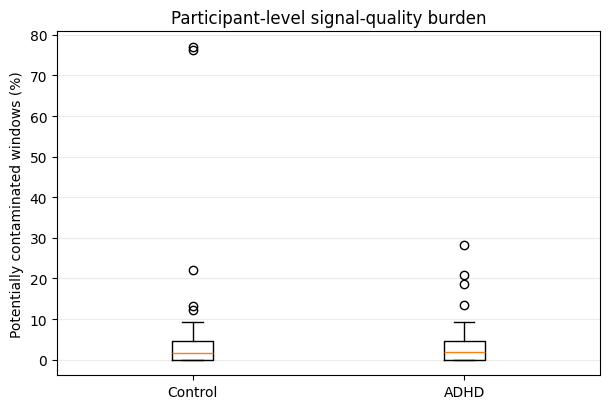

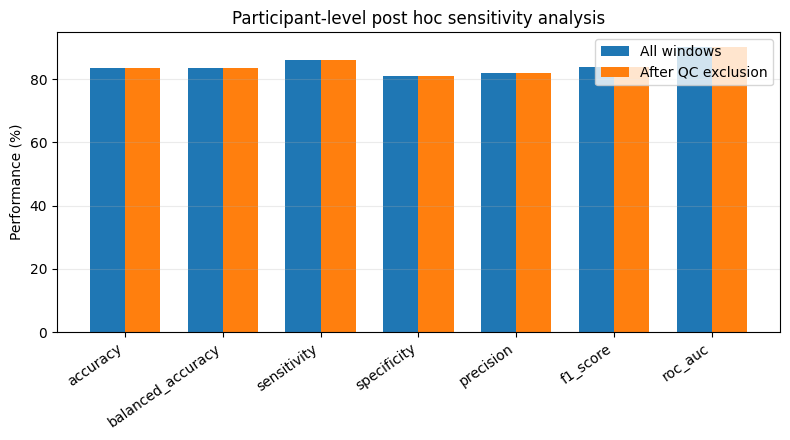

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
control_values = subject_quality.query("y_true == 0")["artifact_rate_percent"]
adhd_values = subject_quality.query("y_true == 1")["artifact_rate_percent"]
ax.boxplot(
    [control_values, adhd_values],
    labels=["Control", "ADHD"],
    showfliers=True,
)
ax.set_ylabel("Potentially contaminated windows (%)")
ax.set_title("Participant-level signal-quality burden")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "artifact_rate_by_diagnostic_group.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.5))
plot_frame = participant_sensitivity_95ci.copy()
x = np.arange(len(plot_frame))
width = 0.36
ax.bar(
    x - width / 2,
    plot_frame["original_percent"],
    width,
    label="All windows",
)
ax.bar(
    x + width / 2,
    plot_frame["filtered_percent"],
    width,
    label="After QC exclusion",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_frame["metric"], rotation=35, ha="right")
ax.set_ylabel("Performance (%)")
ax.set_title("Participant-level post hoc sensitivity analysis")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "participant_performance_before_after_qc.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 10. Guardado de resultados

In [11]:
quality.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_by_window.csv",
    index=False,
)
thresholds.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_robust_thresholds.csv",
    index=False,
)
flag_summary.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_flag_summary.csv",
    index=False,
)
artifact_reason_counts.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_reason_counts.csv",
    index=False,
)
subject_quality.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_by_subject.csv",
    index=False,
)
artifact_burden_summary.to_csv(
    OUTPUT_ROOT / "CTE_Net_signal_quality_group_summary.csv",
    index=False,
)
predictions_with_quality.to_csv(
    OUTPUT_ROOT / "CTE_Net_window_predictions_with_quality_flags.csv",
    index=False,
)
window_metrics_by_fold.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_window_metrics_by_fold.csv",
    index=False,
)
window_metrics_by_seed.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_window_metrics_by_seed.csv",
    index=False,
)
window_metrics_summary.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_window_metrics_summary.csv",
    index=False,
)
window_primary_comparison.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_window_primary_comparison.csv",
    index=False,
)
subject_counts.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_subject_coverage_by_condition.csv",
    index=False,
)
participant_predictions_all_conditions.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_subject_predictions_all_conditions.csv",
    index=False,
)
participant_predictions_by_seed.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_subject_predictions_by_seed.csv",
    index=False,
)
participant_metrics_by_seed.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_subject_metrics_by_seed.csv",
    index=False,
)
participant_sensitivity_95ci.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_subject_metrics_95CI.csv",
    index=False,
)
artifact_prediction_association.to_csv(
    OUTPUT_ROOT / "CTE_Net_artifact_prediction_association.csv",
    index=False,
)

summary_json = {
    "analysis": "post_hoc_artifact_sensitivity_without_retraining",
    "sampling_frequency_hz": FS,
    "window_samples": WINDOW_SAMPLES,
    "window_step_samples": WINDOW_STEP,
    "primary_robust_z_threshold": PRIMARY_ROBUST_Z,
    "alternative_robust_z_thresholds": list(ROBUST_Z_VALUES),
    "n_physical_windows": int(len(quality)),
    "n_flagged_primary": int(quality["artifact_flag"].sum()),
    "flagged_percent_primary": float(100 * quality["artifact_flag"].mean()),
    "n_subjects": int(quality["_subject_key"].nunique()),
    "n_seeds": int(predictions["seed"].nunique()),
    "n_bootstrap": int(N_BOOTSTRAP),
    "reference_windows_per_subject": int(reference_windows_per_subject),
    "n_reference_windows": int(len(quality_reference)),
    "valid_participant_conditions": valid_participant_conditions,
    "invalid_participant_conditions": invalid_participant_conditions,
    "predictions_file": str(predictions_path),
    "eeg_root": str(EEG_ROOT),
}

with open(
    OUTPUT_ROOT / "CTE_Net_artifact_sensitivity_analysis_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(summary_json, file, indent=2, ensure_ascii=False)

print("\n" + "=" * 88)
print("ANÁLISIS COMPLETADO SIN REENTRENAR CTE-Net")
print("=" * 88)
print("Ventanas físicas:", len(quality))
print(
    "Ventanas potencialmente contaminadas (z robusto > 5):",
    int(quality["artifact_flag"].sum()),
    f"({100 * quality['artifact_flag'].mean():.2f}%)",
)
print("Resultados guardados en:", OUTPUT_ROOT)
print("\nTabla principal para revisar:")
display(participant_sensitivity_95ci)


ANÁLISIS COMPLETADO SIN REENTRENAR CTE-Net
Ventanas físicas: 8213
Ventanas potencialmente contaminadas (z robusto > 5): 358 (4.36%)
Resultados guardados en: /kaggle/working/CTE_Net_artifact_quality_sensitivity

Tabla principal para revisar:


,metric,original_percent,original_ci_low,original_ci_high,filtered_percent,filtered_ci_low,filtered_ci_high,difference_percentage_points,difference_ci_low,difference_ci_high,n_bootstrap
0,accuracy,83.416667,78.247917,88.166667,83.500000,78.333333,88.250000,0.083333,0.000000,0.250000,5000
1,balanced_accuracy,83.416667,78.247917,88.166667,83.500000,78.333333,88.250000,0.083333,0.000000,0.250000,5000
2,sensitivity,86.000000,78.833333,92.166667,86.000000,78.833333,92.166667,0.000000,0.000000,0.000000,5000
3,specificity,80.833333,73.000000,87.833333,81.000000,73.000000,88.000000,0.166667,0.000000,0.500000,5000
4,precision,81.849507,75.943500,87.773213,81.984357,76.061830,87.968241,0.134849,0.000000,0.444915,5000
5,f1_score,83.829749,78.736092,88.472961,83.898845,78.823797,88.512855,0.069096,0.000000,0.216654,5000
6,roc_auc,90.244444,85.063819,94.622292,90.152778,84.924653,94.594514,-0.091667,-0.369444,0.097222,5000


## Interpretación

Este análisis evalúa si el rendimiento ya obtenido cambia al retirar, de las
predicciones de prueba, ventanas con indicadores extremos de calidad. No
demuestra que las ventanas conservadas estén libres de artefactos y tampoco
reemplaza una adquisición con canales EOG u otros sensores auxiliares. Sus
resultados deben presentarse como una comprobación de sensibilidad post hoc.